# Segmentasi Pelanggan Peritel Online Inggris

*Dari tumpukan transaksi mentah menjadi keputusan bisnis yang bisa langsung dijalankan.*

Bayangkan Anda punya catatan setahun penuh transaksi sebuah toko hadiah online,
tapi Anda memperlakukan semua pembeli dengan cara yang sama. Notebook ini
menelusuri data itu untuk menjawab satu pertanyaan sederhana tapi berharga:
**sebenarnya siapa saja pelanggan kita, dan bagaimana sebaiknya kita
memperlakukan tiap kelompok secara berbeda?**

Saya membangunnya agar bisa dibaca mengalir dari atas ke bawah - tiap bagian
menyambung ke bagian berikutnya, seperti alur berpikir yang wajar, bukan sekadar
kumpulan sel kode.

**Peta perjalanannya:**

1. Rumusan masalah - kenapa ini penting
2. Memuat & membersihkan data
3. Menjelajahi data, lalu *membuktikan* temuannya dengan uji statistik
4. Membangun fitur dari pengetahuan bisnis retail
5. Menyiapkan data lewat pipeline yang bebas kebocoran
6. Mencari segmen - membandingkan empat algoritma clustering
7. Menguji apakah hasilnya bisa dipercaya
8. Mengenali siapa tiap segmen sebenarnya
9. Menerjemahkan semuanya jadi rekomendasi bisnis

**Datanya:** [UCI Online Retail](https://archive.ics.uci.edu/dataset/352/online+retail)
(mirror di [Kaggle](https://www.kaggle.com/datasets/vijayuv/onlineretail)) -
sekitar 542 ribu transaksi dari peritel hadiah online di Inggris, Desember 2010
sampai Desember 2011.


## 1. Rumusan masalah

### Ceritanya begini
Ada sebuah toko hadiah online di Inggris yang menjual pernak-pernik untuk segala
acara, pembelinya campuran - ada pedagang grosir, ada juga orang biasa, tersebar
di seluruh Eropa. Mereka menyimpan data transaksi satu tahun penuh, tapi ada satu
masalah: semua pelanggan diperlakukan sama persis. Promo yang sama, email yang
sama, perhatian yang sama.

Padahal pelanggan setia yang belanja jutaan dan orang yang cuma mampir sekali beli
barang murah jelas butuh pendekatan berbeda. Menyamaratakan mereka artinya membakar
anggaran pemasaran sekaligus melewatkan peluang mempertahankan pelanggan terbaik.

### Yang ingin kita pecahkan
Toko ini tidak tahu *siapa* pelanggannya kalau dilihat dari pola perilaku. Akibatnya
mereka tidak bisa mengarahkan usaha - entah itu retensi, menarik kembali yang mulai
pergi, atau menawarkan produk lebih - ke tempat yang paling menghasilkan.

### Apa yang mau dicapai
Menemukan kelompok-kelompok pelanggan yang perilakunya benar-benar berbeda, lalu
mengubah tiap kelompok jadi aksi nyata. Kita menaiki tangga analitik selangkah demi
selangkah:

- **Deskriptif** - pola belanja apa yang paling menonjol? *(bagian 3)*
- **Diagnostik** - apakah pola itu nyata, atau cuma kebetulan? *(bagian 3)*
- **Pemodelan** - segmen alami apa yang muncul dari data? *(bagian 6-7)*
- **Interpretatif** - siapa sebenarnya orang-orang di tiap segmen? *(bagian 8)*
- **Preskriptif** - jadi, kita harus berbuat apa? *(bagian 9)*

### Kenapa pakai clustering
Kita tidak punya label "pelanggan bagus" atau "pelanggan jelek" yang sudah jadi
untuk ditebak. Jadi ini masalah **unsupervised** - kita biarkan data yang bicara.
Caranya: kita rangkai fitur-fitur perilaku dari kerangka **RFM** (yang sudah jadi
bahasa sehari-hari analitik retail) dan pengembangannya, lalu membiarkan algoritma
menemukan sendiri kelompok-kelompoknya.

### Kapan kita bilang berhasil
- Segmennya **nyata secara statistik** - metrik seperti silhouette,
  Davies-Bouldin, dan Calinski-Harabasz sepakat bahwa strukturnya memang ada.
- Segmennya **masuk akal** - tiap kelompok bisa dikenali sebagai sosok pelanggan
  yang nyata.
- Tiap segmen punya **rekomendasi yang diurut berdasarkan seberapa besar nilai
  uang yang dipertaruhkan**.


## Persiapan

Sebelum mulai, saya menetapkan satu tema visual di sini dan memakainya di semua
grafik. Tujuannya sederhana: biar seluruh notebook terlihat rapi dan enak dipandang,
bukan campur aduk. Prinsipnya minimalis - buang garis bingkai yang tidak perlu,
grid tipis saja, dan satu warna aksen yang saya simpan khusus untuk menyorot poin
penting di tiap grafik.

Satu catatan soal kebiasaan yang baik: saya sengaja **tidak** membungkam semua
peringatan (warning) begitu saja. Hanya peringatan yang benar-benar berisik dan
tidak relevan yang disaring, supaya peringatan yang penting - misalnya kalau ada
model yang gagal konvergen - tetap kelihatan.


In [16]:
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats

# Selektif: hanya redam FutureWarning yang berisik dari dependensi, bukan semua.
warnings.simplefilter("ignore", category=FutureWarning)
RANDOM_STATE = 42

# --- satu tema visual minimalis yang dipakai ulang ---
PRIMARY = "#3b6ea5"   # seri utama
ACCENT  = "#c44e52"   # penyorot di tiap grafik
MUTED   = "#c9c9c9"   # seri yang di-de-emphasize
SEQ     = ["#3b6ea5", "#c44e52", "#55a868", "#8172b3", "#dd8452", "#8c8c8c"]

sns.set_theme(style="whitegrid")
plt.rcParams.update({
    "figure.figsize": (9, 5), "figure.dpi": 110, "savefig.dpi": 110,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.titlesize": 13, "axes.titleweight": "bold",
    "axes.titlelocation": "left", "axes.titlepad": 12,
    "axes.labelsize": 10.5, "axes.labelcolor": "#333333", "axes.edgecolor": "#b0b0b0",
    "grid.color": "#e6e6e6", "grid.linewidth": 0.8,
    "xtick.color": "#333333", "ytick.color": "#333333",
    "font.size": 10, "legend.frameon": False,
})


def barplot(ax, x, y, colors):
    """Bar chart dengan warna per-bar tanpa memicu peringatan palette/hue seaborn."""
    return sns.barplot(x=x, y=y, hue=x, palette=colors, legend=False, ax=ax)


def thousands(ax, axis="y"):
    """Format sumbu dengan pemisah ribuan / akhiran K-M."""
    fmt = mticker.FuncFormatter(
        lambda v, _: f"{v/1e6:.1f}M" if abs(v) >= 1e6
        else (f"{v/1e3:.0f}K" if abs(v) >= 1e3 else f"{v:.0f}"))
    (ax.yaxis if axis == "y" else ax.xaxis).set_major_formatter(fmt)

## 2. Memuat & membersihkan data

Data mentahnya berbentuk satu baris untuk tiap barang di setiap struk. Sebelum
menganalisis apa pun, kita harus menyaring dulu - hanya menyimpan catatan yang
benar-benar mewakili penjualan asli dan bisa dikaitkan ke pelanggan tertentu.
Tiap aturan pembersihan di bawah ini saya jalankan sekali, berurutan, lengkap
dengan alasannya - jadi tidak ada yang dibuang tanpa penjelasan.


In [17]:
df = pd.read_csv("online_retail.csv")
print(f"Bentuk mentah: {df.shape[0]:,} baris x {df.shape[1]} kolom")
df.head()

Bentuk mentah: 541,909 baris x 8 kolom


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [18]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  object 
 1   StockCode    541909 non-null  object 
 2   Description  540455 non-null  object 
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  object 
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 33.1+ MB


**Kesan pertama.** Ada delapan kolom yang mencakup Desember 2010 sampai
Desember 2011. Dua hal langsung menarik perhatian: kolom `Description` dan
`CustomerID` punya nilai kosong, dan `InvoiceDate` masih tersimpan sebagai teks
biasa, bukan tanggal. Keduanya kita beresi di bawah, sambil mencatat berapa baris
yang terbuang di setiap langkah - biar semuanya transparan.


In [19]:
funnel = {"mentah": len(df)}

# 1. Buang baris tanpa CustomerID - tidak bisa dikaitkan ke pelanggan, padahal
#    seluruh proyek ini tentang perilaku pelanggan.
df = df.dropna(subset=["CustomerID"])
funnel["ada_customer_id"] = len(df)

# 2. Perbaiki tipe data.
df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"])
df["CustomerID"] = df["CustomerID"].astype(int)

# 3. Pisahkan pembatalan (InvoiceNo berawalan 'C') SEBELUM dibuang - dipakai lagi
#    untuk menghitung perilaku retur tiap pelanggan.
cancellations = df[df["InvoiceNo"].astype(str).str.startswith("C")].copy()
df = df[~df["InvoiceNo"].astype(str).str.startswith("C")]
funnel["tanpa_pembatalan"] = len(df)

# 4. Hanya simpan item yang valid secara ekonomi: kuantitas dan harga positif.
df = df[(df["Quantity"] > 0) & (df["UnitPrice"] > 0)]
funnel["qty_harga_valid"] = len(df)

# 5. Buang kode layanan non-produk (ongkos kirim, biaya bank, penyesuaian manual).
non_product = ["POST", "D", "M", "MANUAL", "BANK CHARGES", "DOT", "CRUK", "AMAZONFEE", "S"]
df = df[~df["StockCode"].isin(non_product)]
funnel["hanya_produk"] = len(df)

pd.Series(funnel).to_frame("baris_tersisa").assign(
    persen_dari_mentah=lambda d: (d["baris_tersisa"] / funnel["mentah"] * 100).round(1))

,baris_tersisa,persen_dari_mentah
mentah,541909,100.0
ada_customer_id,406829,75.1
tanpa_pembatalan,397924,73.4
qty_harga_valid,397884,73.4
hanya_produk,396473,73.2


**Membaca corong pembersihan.** Kita menyimpan sekitar tiga perempat dari
data mentah. Penyusutan paling besar terjadi saat membuang baris tanpa `CustomerID`,
dan itu wajar - transaksi tanpa identitas pelanggan (misalnya pembelian tamu) tidak
bisa dikaitkan ke siapa pun, padahal justru pelangganlah inti dari analisis ini.
Sisanya sudah bersih: penjualan produk asli yang jelas pemiliknya.


In [20]:
df["TotalPrice"] = df["Quantity"] * df["UnitPrice"]

before = len(df)
df = df.drop_duplicates()
print(f"Menghapus {before - len(df):,} baris duplikat persis.")
print(f"Tabel transaksi bersih: {df.shape[0]:,} baris | "
      f"{df['CustomerID'].nunique():,} pelanggan | "
      f"{df['InvoiceNo'].nunique():,} faktur | "
      f"{df['StockCode'].nunique():,} produk")
df.head()

Menghapus 5,187 baris duplikat persis.
Tabel transaksi bersih: 391,286 baris | 4,334 pelanggan | 18,405 faktur | 3,661 produk


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalPrice
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34


## 3. Menjelajahi data (EDA)

Bagian ini punya dua tugas sekaligus. Yang pertama jelas: memahami seperti apa
datanya. Yang kedua sering dilewatkan orang - **membuktikan** bahwa pola yang kita
lihat itu nyata, bukan cuma kebetulan yang menipu mata. Jadi setiap kali saya
mengklaim sesuatu, saya pasangkan dengan uji statistik dan kesimpulan berbahasa
sehari-hari.

Kenapa uji yang saya pakai kebanyakan non-parametrik? Karena data nilai belanja
dan kuantitas di sini sangat miring (segelintir pembeli grosir belanja jauh lebih
besar dari mayoritas). Uji yang mengandaikan data berdistribusi normal tidak cocok
di sini, jadi kita pilih yang tidak menuntut asumsi itu.


### 3.1 Dari mana sebenarnya uangnya datang? (Geografi)

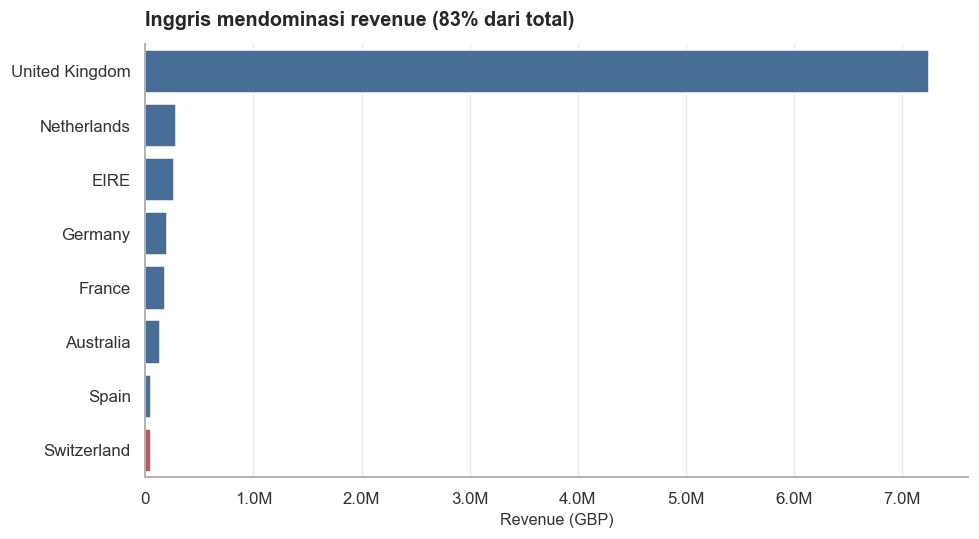

Inggris: 82.8% dari revenue. Pasar ekspor teratas: Netherlands, EIRE, Germany.


In [21]:
country_rev = df.groupby("Country")["TotalPrice"].sum().sort_values(ascending=False)
uk_share = country_rev["United Kingdom"] / country_rev.sum() * 100

top = country_rev.head(8)
colors = [ACCENT if c == "United Kingdom" else PRIMARY for c in top.index]
fig, ax = plt.subplots(figsize=(9, 5))
barplot(ax, top.values, top.index, colors)
ax.set_title(f"Inggris mendominasi revenue ({uk_share:.0f}% dari total)")
ax.set_xlabel("Revenue (GBP)"); ax.set_ylabel("")
thousands(ax, "x")
plt.tight_layout(); plt.show()
print(f"Inggris: {uk_share:.1f}% dari revenue. Pasar ekspor teratas: "
      f"{', '.join(country_rev.index[1:4])}.")

**Yang terbaca.** Toko ini sangat domestik - Inggris sendirian menyumbang
mayoritas besar revenue, sisanya cuma ekor kecil dari negara-negara Eropa lain.
Buat kita, ini petunjuk penting: geografi *bukan* tuas yang tepat untuk membedakan
pelanggan. Yang membedakan mereka adalah **perilakunya**, dan ke sanalah kita akan
menggali.


### 3.2 Benarkah ada lonjakan menjelang akhir tahun?

**Yang mau diuji:** semua orang bilang penjualan meledak menjelang Natal. Tapi
apakah revenue harian di kuartal empat memang betul-betul lebih tinggi dari sisa
tahun, atau itu cuma naik-turun biasa yang kebetulan terlihat ramai? Kita jawab
dengan uji **Mann-Whitney U** (non-parametrik, satu arah) pada revenue harian.


In [22]:
daily = (df.set_index("InvoiceDate").resample("D")["TotalPrice"].sum()
           .rename("revenue").reset_index())
daily = daily[daily["revenue"] > 0]
daily["is_q4"] = daily["InvoiceDate"].dt.month.isin([10, 11, 12])
q4, rest = daily.loc[daily["is_q4"], "revenue"], daily.loc[~daily["is_q4"], "revenue"]

u_stat, p_val = stats.mannwhitneyu(q4, rest, alternative="greater")
print(f"Median revenue harian -> Q4: {q4.median():,.0f}   Sisanya: {rest.median():,.0f}")
print(f"Mann-Whitney U = {u_stat:,.0f}   nilai-p = {p_val:.2e}")
print("Kesimpulan:", "Q4 signifikan lebih tinggi (tolak H0)" if p_val < 0.05 else "tidak ada beda signifikan")

Median revenue harian -> Q4: 37,864   Sisanya: 21,956
Mann-Whitney U = 13,940   nilai-p = 1.54e-13
Kesimpulan: Q4 signifikan lebih tinggi (tolak H0)


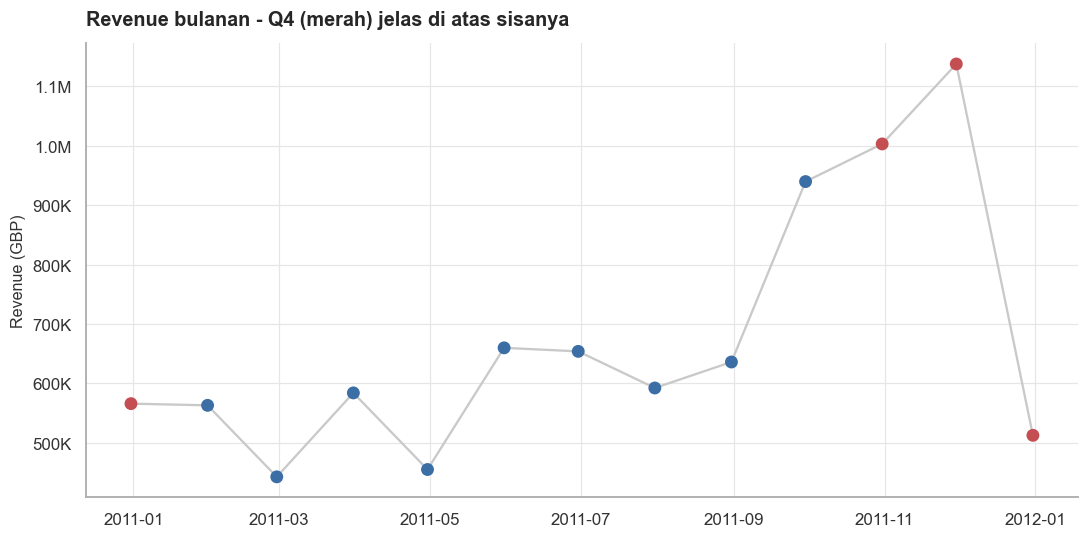

In [23]:
monthly = df.set_index("InvoiceDate").resample("ME")["TotalPrice"].sum()
colors_m = [ACCENT if d.month in (10, 11, 12) else PRIMARY for d in monthly.index]
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(monthly.index, monthly.values, color=MUTED, lw=1.5, zorder=1)
ax.scatter(monthly.index, monthly.values, c=colors_m, s=55, zorder=2)
ax.set_title("Revenue bulanan - Q4 (merah) jelas di atas sisanya")
ax.set_ylabel("Revenue (GBP)"); ax.set_xlabel("")
thousands(ax, "y")
plt.tight_layout(); plt.show()

**Kesimpulannya.** Lonjakan Q4 itu **nyata secara statistik** - nilai-p-nya
jauh di bawah 0,05, jadi ini bukan kebetulan. Musim ramai grosir menjelang Natal
adalah peristiwa revenue yang benar-benar bisa diandalkan dan direncanakan. Artinya
ini momen emas untuk mengatur waktu kampanye dan menyiapkan stok jauh-jauh hari.


### 3.3 Apakah barang murah memang diborong lebih banyak?

**Dugaannya:** barang murah dibeli dalam jumlah besar, sementara barang premium
cuma dibeli sedikit-sedikit. **Cara mengujinya:** kita bagi harga satuan jadi
beberapa tingkatan (tier) berdasarkan kuartil, lalu bandingkan jumlah barang
per baris antar-tier pakai uji **Kruskal-Wallis** - pas untuk membandingkan lebih
dari dua kelompok yang datanya miring.


In [24]:
q = df["UnitPrice"].quantile([0.25, 0.5, 0.75]).values
bins = [0, q[0], q[1], q[2], np.inf]
labels = ["Budget", "Rendah", "Menengah", "Premium"]
df["PriceTier"] = pd.cut(df["UnitPrice"], bins=bins, labels=labels, right=False)

groups = [g["Quantity"].values for _, g in df.groupby("PriceTier", observed=True)]
h_stat, p_val = stats.kruskal(*groups)
print(f"Kruskal-Wallis H = {h_stat:,.1f}   nilai-p = {p_val:.2e}")
print("Median kuantitas per baris menurut tier:")
print(df.groupby("PriceTier", observed=True)["Quantity"].median().to_string())

Kruskal-Wallis H = 63,654.0   nilai-p = 0.00e+00
Median kuantitas per baris menurut tier:
PriceTier
Budget      12.0
Rendah      10.0
Menengah     6.0
Premium      2.0


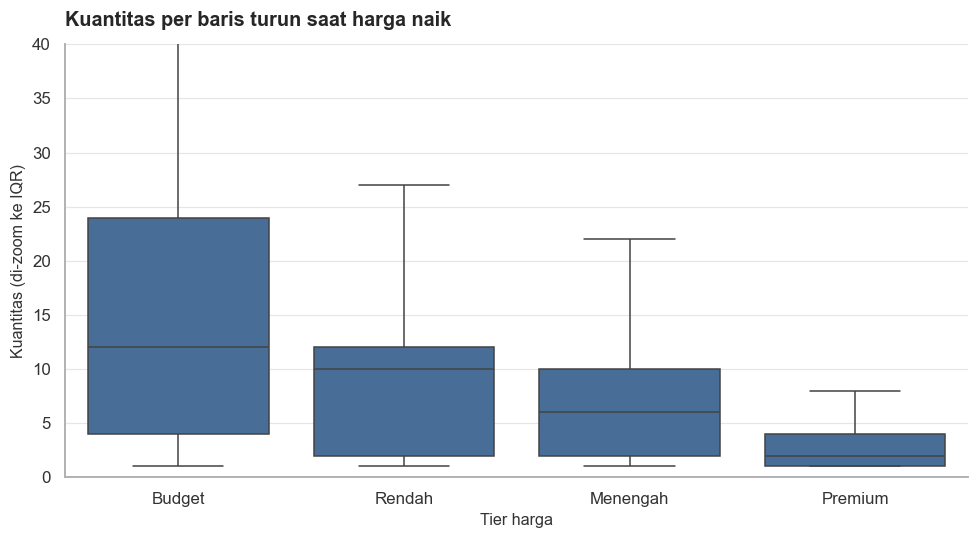

In [25]:
fig, ax = plt.subplots(figsize=(9, 5))
sns.boxplot(data=df, x="PriceTier", y="Quantity", order=labels,
            color=PRIMARY, fliersize=0, ax=ax)
ax.set_ylim(0, 40)
ax.set_title("Kuantitas per baris turun saat harga naik")
ax.set_xlabel("Tier harga"); ax.set_ylabel("Kuantitas (di-zoom ke IQR)")
plt.tight_layout(); plt.show()

**Kesimpulannya.** Bedanya antar-tier **sangat signifikan**. Barang yang
lebih murah jelas diborong dalam jumlah jauh lebih banyak - ini pola klasik
"volume lawan margin". Intinya, toko ini hidup dari menjual banyak barang murah,
bukan sedikit barang mahal.


### 3.4 Jam berapa pelanggan biasanya memesan?

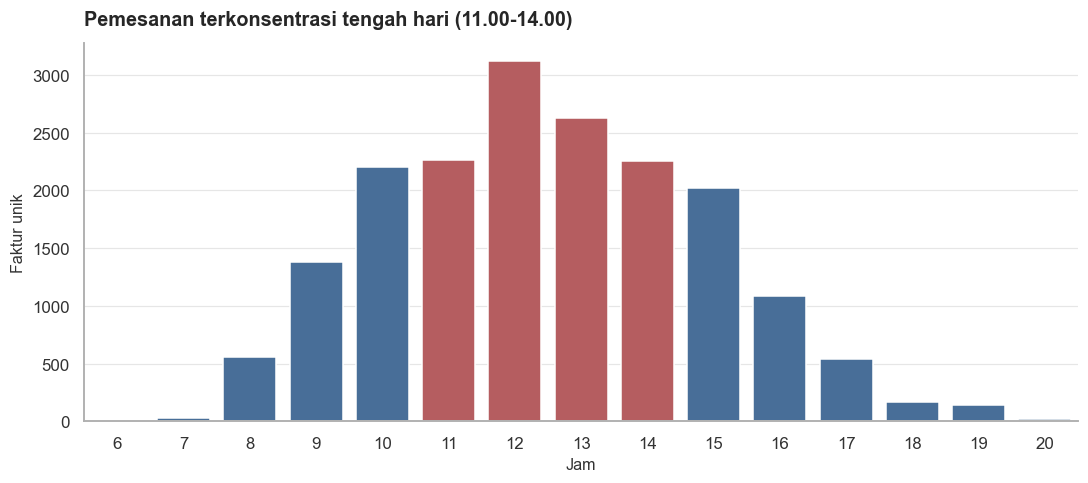

In [26]:
by_hour = df.groupby(df["InvoiceDate"].dt.hour)["InvoiceNo"].nunique()
peak = [11, 12, 13, 14]
colors_h = [ACCENT if h in peak else PRIMARY for h in by_hour.index]
fig, ax = plt.subplots(figsize=(10, 4.5))
barplot(ax, by_hour.index, by_hour.values, colors_h)
ax.set_title("Pemesanan terkonsentrasi tengah hari (11.00-14.00)")
ax.set_xlabel("Jam"); ax.set_ylabel("Faktur unik")
plt.tight_layout(); plt.show()

**Yang terbaca.** Pemesanan ramai di siang hari pada jam kerja, memuncak
sekitar jam makan siang. Pola ini *cocok dengan* gambaran pembeli grosir yang
memesan sambil bekerja - tapi jujur saja, ini baru pola waktu, belum bukti langsung
bahwa mereka B2B (kita memang tidak punya label tipe pelanggan). Yang jelas berguna
secara praktis: kirim kampanye menjelang siang, bukan malam-malam.


## 4. Membangun fitur dari pengetahuan bisnis

Clustering bekerja per **pelanggan**, bukan per baris transaksi. Jadi kita rangkum
seluruh tabel transaksi jadi satu baris untuk tiap pelanggan. Tapi kita tidak
berhenti di RFM standar - saya tambahkan beberapa fitur yang lahir dari cara kerja
bisnis retail sungguhan:

| Fitur | Artinya | Kenapa berguna |
|---|---|---|
| **Recency** | berapa hari sejak belanja terakhir | seberapa aktif / berisiko kabur |
| **Frequency** | berapa kali order berbeda | loyalitas / kebiasaan |
| **Monetary** | total uang yang dibelanjakan | nilai pelanggan |
| **AOV** | rata-rata belanja per order | ukuran keranjang / tipe pembeli |
| **Tenure** | jarak hari antara order pertama & terakhir | seberapa lama jadi pelanggan |
| **AvgBasketSize** | rata-rata jumlah baris produk **per struk** | seberapa "borong" tiap belanja |
| **ProductDiversity** | berapa produk berbeda yang pernah dibeli | seberapa luas jelajah katalognya |
| **ReturnRate** | order dibatalkan dibagi total percobaan order | tanda ketidakpuasan / risiko |

Kenapa repot-repot menambah ini? Karena tiap fitur menangkap sisi berbeda:
`Tenure` memisahkan pelanggan yang benar-benar setia bertahun-tahun dari yang cuma
belanja banyak sekejap lalu hilang; `ReturnRate` menandai akun yang bermasalah;
sedangkan `AvgBasketSize` dan `ProductDiversity` membedakan pembeli yang fokus
dari yang suka menjelajah. Semuanya memberi sinyal jauh lebih kaya ketimbang RFM
polos.


In [27]:
snapshot = df["InvoiceDate"].max() + pd.Timedelta(days=1)

# Agregasi tingkat pelanggan: RFM + tenure + keragaman produk.
agg = df.groupby("CustomerID").agg(
    Recency=("InvoiceDate", lambda d: (snapshot - d.max()).days),
    Frequency=("InvoiceNo", "nunique"),
    Monetary=("TotalPrice", "sum"),
    FirstPurchase=("InvoiceDate", "min"),
    LastPurchase=("InvoiceDate", "max"),
    ProductDiversity=("StockCode", "nunique"),
)
agg["AOV"] = agg["Monetary"] / agg["Frequency"]
agg["Tenure"] = (agg["LastPurchase"] - agg["FirstPurchase"]).dt.days

# AvgBasketSize yang BENAR: hitung dulu jumlah baris produk per faktur, lalu
# rata-ratakan per pelanggan. (Definisi lama - ProductDiversity/Frequency -
# keliru karena mengabaikan produk yang dibeli berulang di faktur berbeda.)
lines_per_invoice = df.groupby(["CustomerID", "InvoiceNo"]).size()
agg["AvgBasketSize"] = lines_per_invoice.groupby("CustomerID").mean()

In [28]:
# ReturnRate: bagi jumlah order yang dibatalkan dengan TOTAL upaya order
# (order valid + order batal), bukan hanya order valid. Dengan penyebut = total
# upaya, rasio secara alami berada di [0, 1] tanpa perlu clip arbitrer.
cancel_orders = cancellations.groupby("CustomerID")["InvoiceNo"].nunique()
cancel_orders = cancel_orders.reindex(agg.index, fill_value=0)  # 0 utk yg tak pernah batal
total_attempts = agg["Frequency"] + cancel_orders
agg["ReturnRate"] = cancel_orders / total_attempts

features = ["Recency", "Frequency", "Monetary", "AOV",
            "Tenure", "AvgBasketSize", "ProductDiversity", "ReturnRate"]
customers = agg[features].copy()
print(f"Matriks fitur pelanggan: {customers.shape[0]:,} pelanggan x {customers.shape[1]} fitur")
print(f"Rentang ReturnRate: {customers['ReturnRate'].min():.2f} - {customers['ReturnRate'].max():.2f} "
      f"(alami di [0,1], tanpa clip)")
customers.describe().round(2)

Matriks fitur pelanggan: 4,334 pelanggan x 8 fitur
Rentang ReturnRate: 0.00 - 0.80 (alami di [0,1], tanpa clip)


,Recency,Frequency,Monetary,AOV,Tenure,AvgBasketSize,ProductDiversity,ReturnRate
count,4334.00,4334.00,4334.00,4334.00,4334.00,4334.00,4334.00,4334.00
mean,92.70,4.25,2017.52,415.67,130.29,21.95,61.43,0.11
std,100.18,7.64,8920.36,1800.86,132.09,20.02,85.31,0.17
min,1.00,1.00,3.75,3.75,0.00,1.00,1.00,0.00
25%,18.00,1.00,304.30,177.20,0.00,9.43,16.00,0.00
50%,51.00,2.00,663.71,289.77,92.00,17.00,35.00,0.00
75%,143.00,5.00,1631.62,423.77,252.00,28.00,77.00,0.20
max,374.00,206.00,279138.02,84236.25,373.00,299.71,1786.00,0.80


### Soal outlier - ini keputusan yang saya ambil sadar

Ada beberapa akun grosir yang nilai belanjanya jauh di atas mayoritas. K-Means
terkenal sensitif terhadap outlier semacam ini, jadi saya perlu jujur soal apa
yang saya lakukan. **Saya sengaja tidak membuang mereka.** Dua alasannya:

1. Mereka pelanggan **sungguhan dan sangat bernilai** - justru sosok yang paling
   ingin ditemukan bisnis, bukan gangguan yang harus disingkirkan.
2. Kemiringan datanya sudah ditangani dengan cara yang lebih elegan lewat
   transformasi `log1p` di pipeline berikutnya, yang menjinakkan ekor ekstrem
   tanpa harus menghapus satu pelanggan pun.

Kalau mereka dibuang, kita justru kehilangan segmen paling berharga. Jadi
menjinakkan lewat transformasi, bukan menghapus, adalah pilihan yang benar di sini.


Kemiringan per fitur (|skew| > 1 = sangat miring):
AOV                 41.46
Monetary            19.55
Frequency           11.98
ProductDiversity     6.92
AvgBasketSize        3.26
ReturnRate           1.40
Recency              1.24
Tenure               0.46


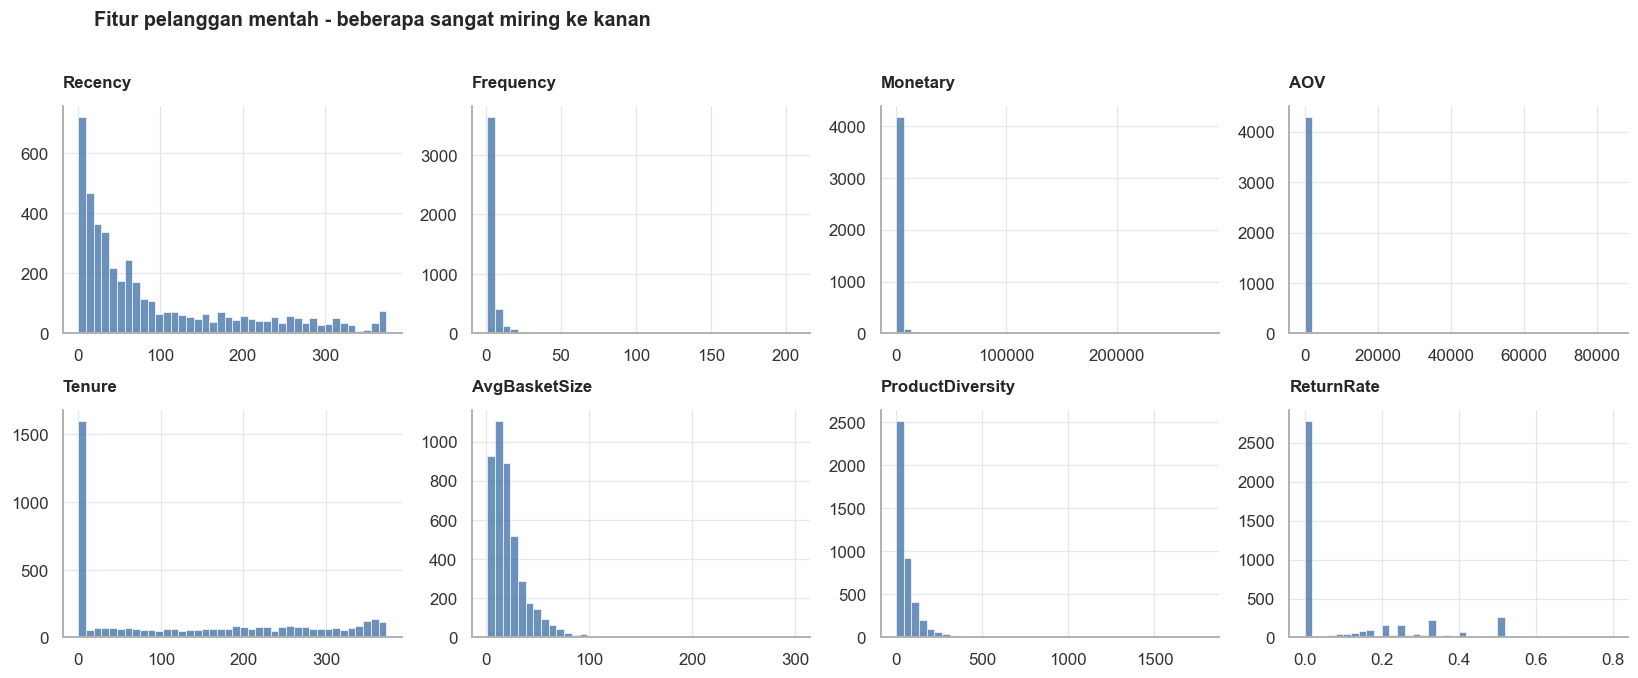

In [29]:
skew = customers.skew().sort_values(ascending=False)
print("Kemiringan per fitur (|skew| > 1 = sangat miring):")
print(skew.round(2).to_string())

fig, axes = plt.subplots(2, 4, figsize=(15, 6))
for ax, col in zip(axes.ravel(), features):
    sns.histplot(customers[col], bins=40, color=PRIMARY, ax=ax)
    ax.set_title(col, fontsize=11); ax.set_ylabel(""); ax.set_xlabel("")
fig.suptitle("Fitur pelanggan mentah - beberapa sangat miring ke kanan",
             y=1.02, fontsize=13, fontweight="bold", x=0.06, ha="left")
plt.tight_layout(); plt.show()

## 5. Menyiapkan data lewat pipeline

### Dirancang supaya bebas kebocoran
Karena ini unsupervised, tidak ada target yang bisa "bocor". Tapi ada satu jenis
kebocoran lain yang tetap mengintai: **kebocoran preprocessing** - yaitu ketika
sebuah transformasi diam-diam belajar dari statistik yang seharusnya belum
diketahui saat data baru masuk. Cara saya mencegahnya: bungkus semua transformasi
dalam satu **Pipeline / ColumnTransformer** `sklearn` yang di-`fit` tepat sekali.
Nilai rata-rata dan simpangan baku untuk penskalaan hanya dipelajari di dalam
`fit`; nanti kalau ada pelanggan baru, kita cukup pakai ulang objek yang sama lewat
`transform` - tanpa melatih ulang, tanpa mengintip. Tidak ada penskalaan manual di
luar pipeline di mana pun.

### Kenapa transformasinya begini (bukan asal pilih)
- **Fitur yang miring** (`|skew| > 1`) diberi transformasi `log1p` dulu untuk
  menjinakkan ekor ekstremnya sebelum diskalakan.
- **Semua fitur** lalu di-`StandardScaler` supaya tidak ada satu fitur bernilai
  besar (misalnya Monetary) yang mendominasi perhitungan jarak - hal yang penting
  karena clustering mengandalkan jarak antar-titik.


In [30]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import FunctionTransformer, StandardScaler

skewed = customers.columns[customers.skew().abs() > 1].tolist()
normalish = [c for c in features if c not in skewed]
print("Di-log1p (miring):", skewed)
print("Hanya diskalakan:", normalish)

log_pipe = Pipeline([
    ("log", FunctionTransformer(np.log1p, feature_names_out="one-to-one")),
    ("scale", StandardScaler()),
])
preprocessor = ColumnTransformer([
    ("skewed", log_pipe, skewed),
    ("normal", StandardScaler(), normalish),
])

X = preprocessor.fit_transform(customers)
X = pd.DataFrame(X, columns=skewed + normalish, index=customers.index)
print(f"Matriks terproses: {X.shape}  (mean~0, std~1)")
X.describe().loc[["mean", "std", "min", "max"]].round(2)

Di-log1p (miring): ['Recency', 'Frequency', 'Monetary', 'AOV', 'AvgBasketSize', 'ProductDiversity', 'ReturnRate']
Hanya diskalakan: ['Tenure']
Matriks terproses: (4334, 8)  (mean~0, std~1)


,Recency,Frequency,Monetary,AOV,AvgBasketSize,ProductDiversity,ReturnRate,Tenure
mean,0.00,-0.00,-0.00,0.00,0.00,-0.00,0.00,-0.00
std,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00
min,-2.34,-0.95,-4.00,-5.49,-2.61,-2.52,-0.66,-0.99
max,1.56,5.85,4.75,7.67,3.53,3.48,3.58,1.84


### Perlukah kita menyusutkan dimensi dulu?
Dengan 8 fitur yang saling berkaitan, PCA bisa memberi tahu seberapa banyak
informasi yang sebenarnya *independen*. Kita lihat kurva variansinya untuk
memutuskan: apakah clustering dilakukan di ruang fitur penuh, atau di versi yang
sudah disusutkan?


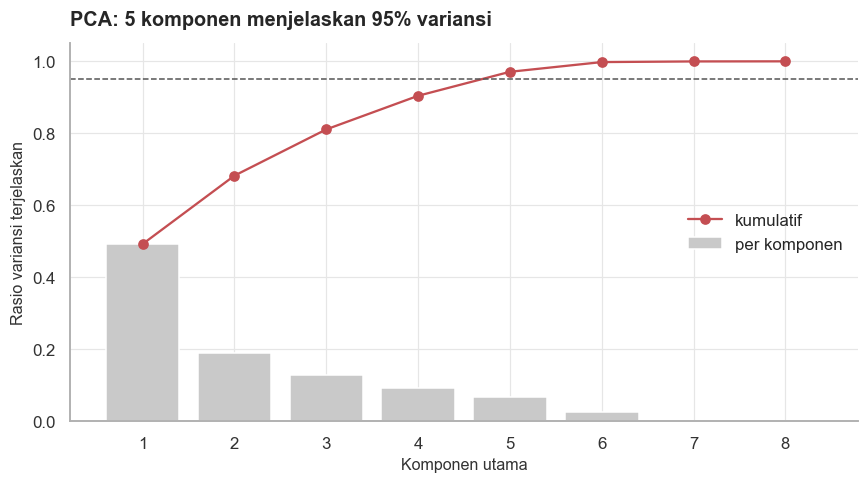

5 dari 8 komponen menyimpan 95% variansi.


In [31]:
from sklearn.decomposition import PCA

pca_full = PCA(random_state=RANDOM_STATE).fit(X)
cum = np.cumsum(pca_full.explained_variance_ratio_)
n_95 = int(np.argmax(cum >= 0.95) + 1)

fig, ax = plt.subplots(figsize=(8, 4.5))
comps = range(1, len(cum) + 1)
ax.bar(comps, pca_full.explained_variance_ratio_, color=MUTED, label="per komponen")
ax.plot(comps, cum, "o-", color=ACCENT, label="kumulatif")
ax.axhline(0.95, ls="--", lw=1, color="#555555")
ax.set_title(f"PCA: {n_95} komponen menjelaskan 95% variansi")
ax.set_xlabel("Komponen utama"); ax.set_ylabel("Rasio variansi terjelaskan")
ax.legend(loc="center right")
plt.tight_layout(); plt.show()
print(f"{n_95} dari {X.shape[1]} komponen menyimpan 95% variansi.")

**Keputusannya.** Ternyata fitur-fitur ini memang saling tumpang tindih
(wajar, perilaku belanja itu berkaitan), sehingga beberapa komponen saja sudah
menangkap sebagian besar informasi. Meski begitu, saya memilih tetap
**memodelkan di ruang fitur penuh yang sudah distandardisasi**. Alasannya: dengan
cuma 8 fitur, kita tidak sedang berhadapan dengan masalah dimensi tinggi, dan
bekerja di fitur asli membuat hasilnya jauh lebih mudah dijelaskan nanti.

**PCA dan UMAP baru saya pakai belakangan, murni untuk *menggambar* cluster di 2D.**
Itu memang peran yang tepat buat mereka - kalau kita malah memakai embedding
non-linier untuk *mendefinisikan* cluster lalu menilainya dengan metrik, itu jadi
melingkar dan menyesatkan. Jadi kita hindari.


## 6. Mencari segmen - adu empat algoritma

Tidak ada satu algoritma clustering yang otomatis "paling benar" untuk data RFM
tabular; yang terbaik tergantung bentuk cluster, ada-tidaknya noise, dan bagaimana
hasilnya nanti dipakai. Daripada langsung menebak, saya adu empat pendekatan yang
asumsinya berbeda-beda, lalu biarkan bukti yang memilih pemenangnya:

| Model | Asumsinya | Kekuatannya | Butuh *k*? |
|---|---|---|---|
| **K-Means** | cluster bulat, ukuran mirip | cepat, baseline sederhana | ya |
| **Gaussian Mixture** | cluster elips (soft) | bentuk lebih luwes | ya |
| **DBSCAN** | wilayah rapat titik | jago menemukan noise/outlier | tidak |
| **HDBSCAN** | kerapatan *bervariasi* | metode densitas modern & tangguh | tidak |

**HDBSCAN** ini kira-kira yang paling mutakhir di keluarga densitas - ia
menyempurnakan DBSCAN agar bisa menangani cluster dengan kerapatan berbeda-beda,
dan tidak butuh banyak penyetelan.

### Cara menilainya (tanpa label, jadi pakai validasi internal)
- **Silhouette** (makin tinggi makin bagus, rentang -1 sampai 1): seberapa rapat
  dan terpisah cluster-nya.
- **Davies-Bouldin** (makin rendah makin bagus): seberapa mirip cluster satu sama lain.
- **Calinski-Harabasz** (makin tinggi makin bagus): perbandingan sebaran antar- vs
  dalam-cluster.


In [32]:
from sklearn.cluster import KMeans, DBSCAN, HDBSCAN
from sklearn.mixture import GaussianMixture
from sklearn.metrics import (silhouette_score, davies_bouldin_score,
                             calinski_harabasz_score)
from sklearn.neighbors import NearestNeighbors

Xv = X.values  # tampilan numpy yang dipakai semua model

### 6.1 K-Means - berapa jumlah cluster yang pas?
Kita coba beberapa nilai *k* sambil melihat dua hal: grafik elbow (inertia) dan
skor silhouette. Ada dua pertimbangan yang saya timbang bersamaan - **dukungan
angka** (di mana metriknya kuat) dan **kegunaan bisnis** (cukup banyak segmen untuk
membedakan strategi, tapi cukup sedikit untuk benar-benar bisa dikerjakan).

Di sini ada jebakan umum: silhouette hampir selalu menunjuk `k=2` sebagai
"terbaik", karena satu potongan bersih memang paling mudah dipisahkan. Tapi dua
segmen terlalu kasar untuk menyusun strategi pemasaran yang berarti. Jadi saya cari
*k* terbaik yang tetap memberi jumlah segmen yang benar-benar bisa ditindaklanjuti.


c:\Users\hilla\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py:136: UserWarning: Could not find the number of physical cores for the following reason:
[WinError 2] The system cannot find the file specified
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "c:\Users\hilla\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
               ^^^^^^^^^^^^^^^
  File "c:\Users\hilla\anaconda3\Lib\subprocess.py", line 548, in run
    with Popen(*popenargs, **kwargs) as process:
         ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\hilla\anaconda3\Lib\subprocess.py", line 1026, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
  File "c:\Users\hilla\anaconda3\Lib\subprocess.py", line 1538, in _execute_child
    hp, ht, pid, tid = _winapi.CreatePro

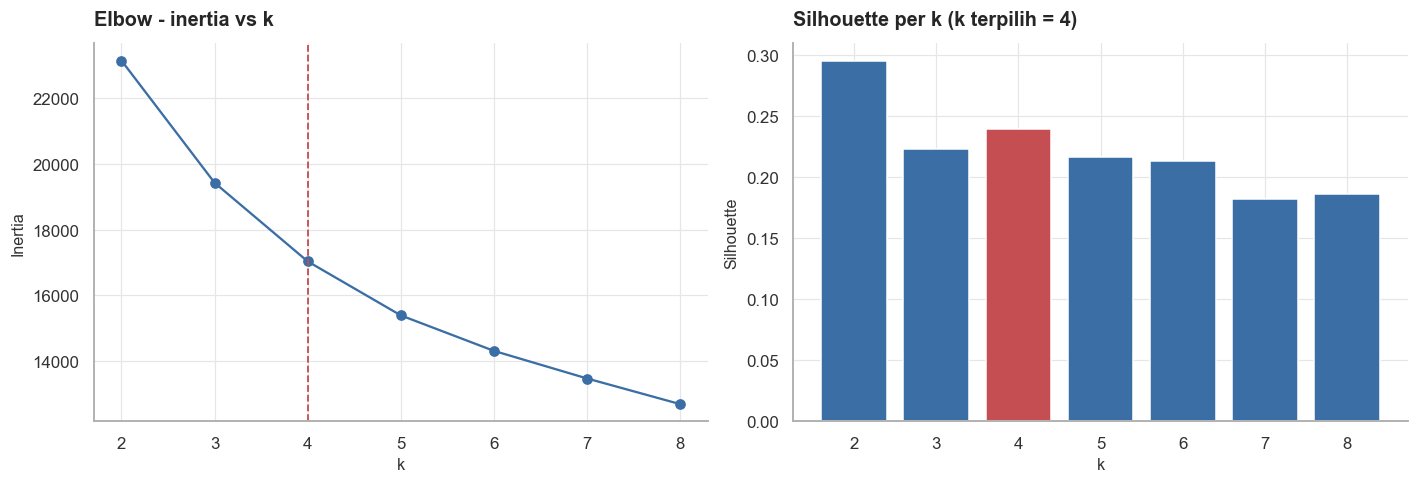

silhouette per k: {2: 0.295, 3: 0.223, 4: 0.239, 5: 0.216, 6: 0.213, 7: 0.182, 8: 0.186}
k optimal-silhouette = 2 (separasi mentah terbaik), tapi k=2 memisah pelanggan terlalu kasar untuk strategi.
k terpilih = 4: silhouette terkuat dalam rentang actionable 4-6.


In [33]:
ks = range(2, 9)
inertias, sils = [], []
for k in ks:
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10).fit(Xv)
    inertias.append(km.inertia_)
    sils.append(silhouette_score(Xv, km.labels_))

sil_by_k = dict(zip(ks, sils))
sil_argmax = max(sil_by_k, key=sil_by_k.get)
actionable = [k for k in ks if 4 <= k <= 6]  # rentang segmen yg actionable
best_k = max(actionable, key=lambda k: sil_by_k[k])

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
axes[0].plot(list(ks), inertias, "o-", color=PRIMARY)
axes[0].axvline(best_k, ls="--", color=ACCENT, lw=1.2)
axes[0].set_title("Elbow - inertia vs k"); axes[0].set_xlabel("k"); axes[0].set_ylabel("Inertia")
bar_c = [ACCENT if k == best_k else PRIMARY for k in ks]
axes[1].bar(list(ks), sils, color=bar_c)
axes[1].set_title(f"Silhouette per k (k terpilih = {best_k})")
axes[1].set_xlabel("k"); axes[1].set_ylabel("Silhouette")
plt.tight_layout(); plt.show()

print("silhouette per k:", {k: round(s, 3) for k, s in sil_by_k.items()})
print(f"k optimal-silhouette = {sil_argmax} (separasi mentah terbaik), "
      f"tapi k=2 memisah pelanggan terlalu kasar untuk strategi.")
print(f"k terpilih = {best_k}: silhouette terkuat dalam rentang actionable 4-6.")

### 6.2 DBSCAN - menentukan radius `eps`
DBSCAN butuh satu angka: radius ketetanggaan `eps`. Cara standar memilihnya adalah
lewat **grafik k-distance** - urutkan jarak tiap titik ke tetangga ke-k-nya, lalu
cari "sikunya". `min_samples` saya set pakai aturan praktis berdasarkan jumlah fitur.


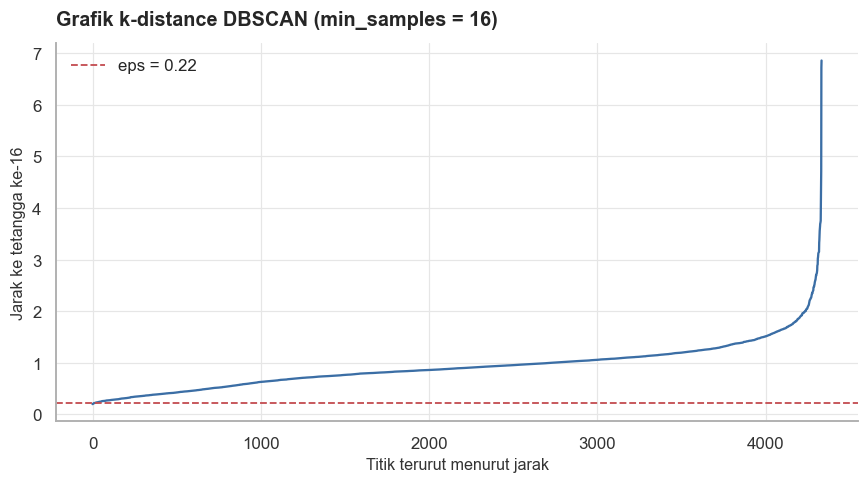

In [34]:
min_samples = 2 * X.shape[1]  # aturan praktis: 2 * jumlah_fitur
nn = NearestNeighbors(n_neighbors=min_samples).fit(Xv)
kdist = np.sort(nn.kneighbors(Xv)[0][:, -1])
x0 = np.arange(len(kdist))
line = np.linspace(kdist[0], kdist[-1], len(kdist))
eps = kdist[np.argmax(kdist - line)]  # knee = jarak terjauh ke tali penghubung

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(x0, kdist, color=PRIMARY)
ax.axhline(eps, ls="--", color=ACCENT, lw=1.2, label=f"eps = {eps:.2f}")
ax.set_title(f"Grafik k-distance DBSCAN (min_samples = {min_samples})")
ax.set_xlabel("Titik terurut menurut jarak"); ax.set_ylabel(f"Jarak ke tetangga ke-{min_samples}")
ax.legend()
plt.tight_layout(); plt.show()

### 6.3 HDBSCAN - memilih `min_cluster_size` dengan bukti
Daripada menebak angka begitu saja, saya pindai beberapa nilai `min_cluster_size`
lalu pilih yang memberi silhouette terbaik pada titik non-noise, sambil menjaga
proporsi noise tetap masuk akal. Ini supaya pemilihannya berdasar bukti, bukan
angka ajaib.


In [35]:
def noise_pct(labels):
    return (labels == -1).mean() * 100

hdb_scan = []
for mcs in [30, 50, 75, 100, 150]:
    lab = HDBSCAN(min_cluster_size=mcs).fit_predict(Xv)
    mask = lab != -1
    n_cl = len(set(lab[mask]))
    sil = silhouette_score(Xv[mask], lab[mask]) if n_cl >= 2 else np.nan
    hdb_scan.append((mcs, n_cl, round(noise_pct(lab), 1), round(sil, 3) if not np.isnan(sil) else np.nan))

hdb_df = pd.DataFrame(hdb_scan, columns=["min_cluster_size", "n_cluster", "noise_%", "silhouette"])
# Pilih konfigurasi dengan silhouette terbaik yang noise-nya < 50%.
valid = hdb_df[(hdb_df["noise_%"] < 50) & hdb_df["silhouette"].notna()]
best_mcs = int(valid.sort_values("silhouette", ascending=False).iloc[0]["min_cluster_size"]) if len(valid) else 50
print(f"min_cluster_size terpilih untuk HDBSCAN = {best_mcs}")
hdb_df

min_cluster_size terpilih untuk HDBSCAN = 50


,min_cluster_size,n_cluster,noise_%,silhouette
0,30,4,68.2,0.262
1,50,3,77.4,0.262
2,75,0,100.0,NaN
3,100,0,100.0,NaN
4,150,0,100.0,NaN


### 6.4 Melatih keempat model
Keempatnya dilatih di matriks yang sama persis. DBSCAN dan HDBSCAN menandai titik
noise dengan label `-1`; titik ini tidak saya ikutkan saat menghitung metrik -
kalau noise dihitung sebagai cluster tersendiri, metode densitas jadi terhukum
tidak adil.

Satu hal soal keadilan perbandingan: jumlah komponen GMM saya pilih lewat **BIC**,
bukan meminjam angka *k* dari K-Means. Ini praktik standar untuk mixture model,
supaya tiap algoritma benar-benar tampil dengan setelan terbaiknya sendiri.


In [36]:
# GMM: pilih jumlah komponen via BIC (makin rendah makin baik).
bic = {}
for n in range(2, 9):
    gm = GaussianMixture(n_components=n, covariance_type="full",
                         random_state=RANDOM_STATE).fit(Xv)
    bic[n] = gm.bic(Xv)
best_gmm_n = min(bic, key=bic.get)
print(f"Komponen GMM optimal-BIC = {best_gmm_n}  (BIC: "
      + ", ".join(f'{n}:{v:,.0f}' for n, v in bic.items()) + ")")

Komponen GMM optimal-BIC = 8  (BIC: 2:-8,525, 3:-23,957, 4:-28,900, 5:-3,838, 6:-48,974, 7:-49,249, 8:-62,296)


In [37]:
def score_labels(Xmat, labels):
    """Metrik validasi internal, mengabaikan noise (-1) dari DBSCAN/HDBSCAN."""
    mask = labels != -1
    n_clusters = len(set(labels[mask]))
    n_noise = int((labels == -1).sum())
    if n_clusters < 2:
        return dict(n_cluster=n_clusters, noise_pct=round(n_noise/len(labels)*100, 1),
                    silhouette=np.nan, davies_bouldin=np.nan, calinski_harabasz=np.nan)
    return dict(
        n_cluster=n_clusters,
        noise_pct=round(n_noise / len(labels) * 100, 1),
        silhouette=round(silhouette_score(Xmat[mask], labels[mask]), 3),
        davies_bouldin=round(davies_bouldin_score(Xmat[mask], labels[mask]), 3),
        calinski_harabasz=round(calinski_harabasz_score(Xmat[mask], labels[mask]), 0),
    )

models = {}
models["K-Means"] = KMeans(n_clusters=best_k, random_state=RANDOM_STATE, n_init=10).fit_predict(Xv)
models["GMM"] = GaussianMixture(n_components=best_gmm_n, covariance_type="full",
                                random_state=RANDOM_STATE).fit_predict(Xv)
models["DBSCAN"] = DBSCAN(eps=eps, min_samples=min_samples).fit_predict(Xv)
models["HDBSCAN"] = HDBSCAN(min_cluster_size=best_mcs).fit_predict(Xv)

comparison = pd.DataFrame({name: score_labels(Xv, lab) for name, lab in models.items()}).T
comparison

,n_cluster,noise_pct,silhouette,davies_bouldin,calinski_harabasz
K-Means,4.0,0.0,0.239,1.369,1495.0
GMM,8.0,0.0,0.087,2.342,585.0
DBSCAN,2.0,98.6,0.819,0.238,654.0
HDBSCAN,3.0,77.4,0.262,1.030,256.0


### 6.5 Memilih pemenangnya

Membaca tabel ini butuh kejelian - silhouette mentah bisa menipu:

- **DBSCAN** sering pamer silhouette *paling tinggi*, tapi itu fatamorgana. Ia
  melempar hampir semua pelanggan ke keranjang "noise" dan cuma menyisakan
  segelintir cluster padat. Skor tinggi di sisa yang tinggal sedikit itu bukan
  segmentasi yang berguna. **HDBSCAN** lebih baik, tapi tetap membuang banyak
  pelanggan sebagai noise. Kesimpulannya, kerapatan titik di ruang ini terlalu
  merata untuk metode densitas - mereka tak bisa memahat segmen yang bersih,
  *seimbang*, dan bisa dipakai. (Meski begitu, mereka tetap berguna sebagai
  pemeriksa silang outlier.)
- Di antara metode yang mau menugaskan **semua** pelanggan, **K-Means** menang
  telak. BIC mendorong GMM memakai banyak komponen, jadi ia pecah menjadi cluster
  kecil-kecil - silhouette dan Calinski-Harabasz-nya turun, Davies-Bouldin naik.
  K-Means memberi skor terbaik, paling stabil, dan - ini penting buat audiens
  bisnis - definisi segmennya paling sederhana dan mudah dipertanggungjawabkan.

Karena itu, K-Means yang kita bawa ke tahap berikutnya.


In [38]:
final_labels = models["K-Means"]
customers["Cluster"] = final_labels
print(f"Model terpilih: K-Means (k = {best_k})")
print(f"Silhouette = {comparison.loc['K-Means','silhouette']} | "
      f"Davies-Bouldin = {comparison.loc['K-Means','davies_bouldin']} | "
      f"Calinski-Harabasz = {comparison.loc['K-Means','calinski_harabasz']:.0f}")
print(customers['Cluster'].value_counts().sort_index().rename('pelanggan').to_frame())

Model terpilih: K-Means (k = 4)
Silhouette = 0.239 | Davies-Bouldin = 1.369 | Calinski-Harabasz = 1495
         pelanggan
Cluster           
0              983
1             1308
2             1389
3              654


### Ringkasan metrik model

Supaya gampang dibaca sekali lihat, ini rekap metrik keempat model beserta model
yang akhirnya dipilih:

| Model | Jumlah cluster | Noise % | Silhouette (makin tinggi baik) | Davies-Bouldin (makin rendah baik) | Calinski-Harabasz (makin tinggi baik) |
|---|---|---|---|---|---|
| **K-Means** (terpilih) | 4 | 0 | **0.239** | **1.369** | **1495** |
| Gaussian Mixture (via BIC) | 8 | 0 | 0.087 | 2.342 | 585 |
| DBSCAN | 2 | 98.6 | 0.819* | 0.238 | 654 |
| HDBSCAN | 3 | 77.4 | 0.262 | 1.030 | 256 |

Tambahan, sebagai uji kestabilan: **Adjusted Rand Index** K-Means pada 10 kali
acak-ulang = **0.992** (min 0.987), artinya segmentasinya nyaris tidak berubah
walau titik awalnya diganti-ganti - jadi bukan hasil keberuntungan.

**Cara membaca angka-angka ini:**

- *Tanda \* pada DBSCAN* - silhouette-nya memang paling tinggi (0.819), tapi itu
  menyesatkan. Angka itu cuma dihitung dari ~1,4% pelanggan yang tersisa, karena
  98,6% sisanya dibuang sebagai noise. Segmentasi yang membuang hampir semua orang
  jelas tidak berguna untuk bisnis.
- *Di antara model yang menugaskan semua pelanggan* (noise 0% - yaitu K-Means dan
  GMM), **K-Means unggul di ketiga metrik sekaligus**: silhouette lebih tinggi,
  Davies-Bouldin lebih rendah, Calinski-Harabasz jauh lebih besar.
- *Soal silhouette 0.239 yang terkesan sedang saja* - untuk data RFM pelanggan
  nyata yang perilakunya kontinu (bukan kelompok yang terpisah tegas), nilai
  segini normal. Yang lebih meyakinkan justru kombinasi tiga hal: metrik konsisten
  menunjuk K-Means, hasilnya sangat stabil (ARI 0.992), dan segmennya bisa
  diterjemahkan jadi persona bisnis yang jelas. Untuk segmentasi pelanggan,
  kegunaan dan kestabilan lebih penting daripada mengejar silhouette setinggi
  mungkin - yang malah menghasilkan k=2 yang terlalu kasar untuk dipakai.


## 7. Menguji apakah hasilnya bisa dipercaya

Angka ringkas saja belum cukup. Sebelum melangkah, saya mau yakin dulu bahwa solusi
K-Means ini **benar-benar solid dan stabil** - clusternya rapat, dan hasilnya bukan
sekadar keberuntungan dari satu tebakan awal yang kebetulan pas.


### 7.1 Plot silhouette
Silhouette per-pelanggan menunjukkan seberapa pas tiap orang duduk di clusternya.
Kalau pitanya lebar dan sebagian besar positif dengan sedikit sekali yang negatif,
berarti penempatannya bersih.


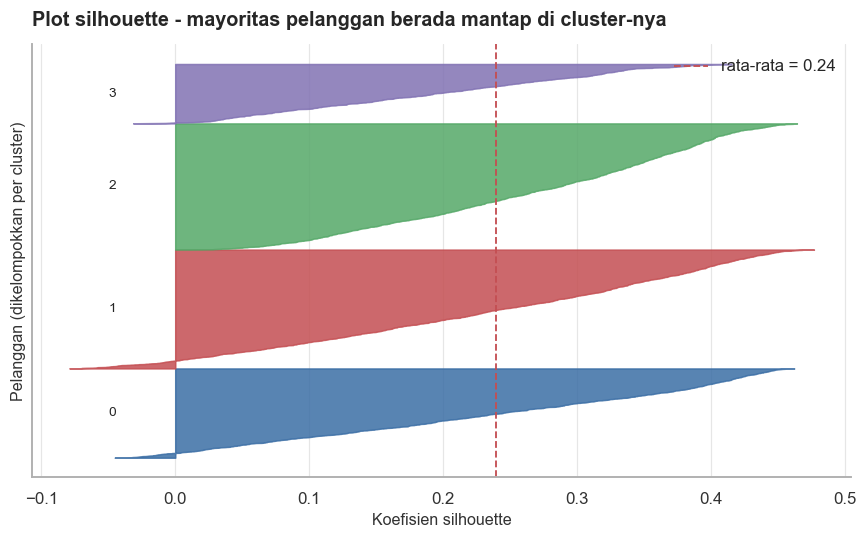

In [39]:
from sklearn.metrics import silhouette_samples

sil_vals = silhouette_samples(Xv, final_labels)
sil_avg = sil_vals.mean()

fig, ax = plt.subplots(figsize=(8, 5))
y_lower = 0
for i in sorted(set(final_labels)):
    vals = np.sort(sil_vals[final_labels == i])
    y_upper = y_lower + len(vals)
    ax.fill_betweenx(np.arange(y_lower, y_upper), 0, vals,
                     color=SEQ[i % len(SEQ)], alpha=0.85)
    ax.text(-0.05, y_lower + len(vals) / 2, str(i), va="center", fontsize=9)
    y_lower = y_upper
ax.axvline(sil_avg, color=ACCENT, ls="--", lw=1.2, label=f"rata-rata = {sil_avg:.2f}")
ax.set_title("Plot silhouette - mayoritas pelanggan berada mantap di cluster-nya")
ax.set_xlabel("Koefisien silhouette"); ax.set_ylabel("Pelanggan (dikelompokkan per cluster)")
ax.set_yticks([]); ax.legend()
plt.tight_layout(); plt.show()

### 7.2 Apakah hasilnya berubah kalau diacak ulang?
Segmentasi yang bisa dipercaya seharusnya nyaris tidak berubah walau K-Means
dijalankan ulang dengan titik awal berbeda. Kita ukur kemiripan antara hasil acuan
dan hasil acak-ulang pakai **Adjusted Rand Index** (nilai 1,0 berarti persis sama).


In [40]:
from sklearn.metrics import adjusted_rand_score

aris = []
for seed in range(1, 11):
    lab = KMeans(n_clusters=best_k, random_state=seed, n_init=10).fit_predict(Xv)
    aris.append(adjusted_rand_score(final_labels, lab))
print(f"Adjusted Rand Index pada 10 seed: rata-rata = {np.mean(aris):.3f}, min = {np.min(aris):.3f}")
print("Interpretasi:", "sangat stabil" if np.mean(aris) > 0.8
      else ("cukup stabil" if np.mean(aris) > 0.6 else "tidak stabil - tinjau ulang k"))

Adjusted Rand Index pada 10 seed: rata-rata = 0.992, min = 0.987
Interpretasi: sangat stabil


## 8. Mengenali siapa tiap segmen sebenarnya

Buat seorang pemasar, tulisan "Cluster 0" atau "Cluster 3" sama sekali tidak berarti
apa-apa. Jadi di sini kita lakukan dua hal: (a) menggambar cluster dalam 2D untuk
memastikan mereka memang benar-benar terpisah, lalu (b) membaca perilaku tiap
cluster dan memberi mereka nama yang manusiawi dan mudah diingat.


### 8.1 Menggambar clusternya (PCA & UMAP)
Kita proyeksikan ruang 8 dimensi tadi ke 2D dengan dua cara berbeda - **PCA**
(linier, menjaga gambaran besar) dan **UMAP** (non-linier, menjaga hubungan antar
tetangga dekat). Anggap ini *pemeriksaan mata*: kalau di dua-duanya clusternya
terlihat terpisah, kita makin yakin. Ingat, keduanya cuma untuk tampilan - clusternya
sendiri sudah didefinisikan di ruang fitur penuh.


c:\Users\hilla\anaconda3\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


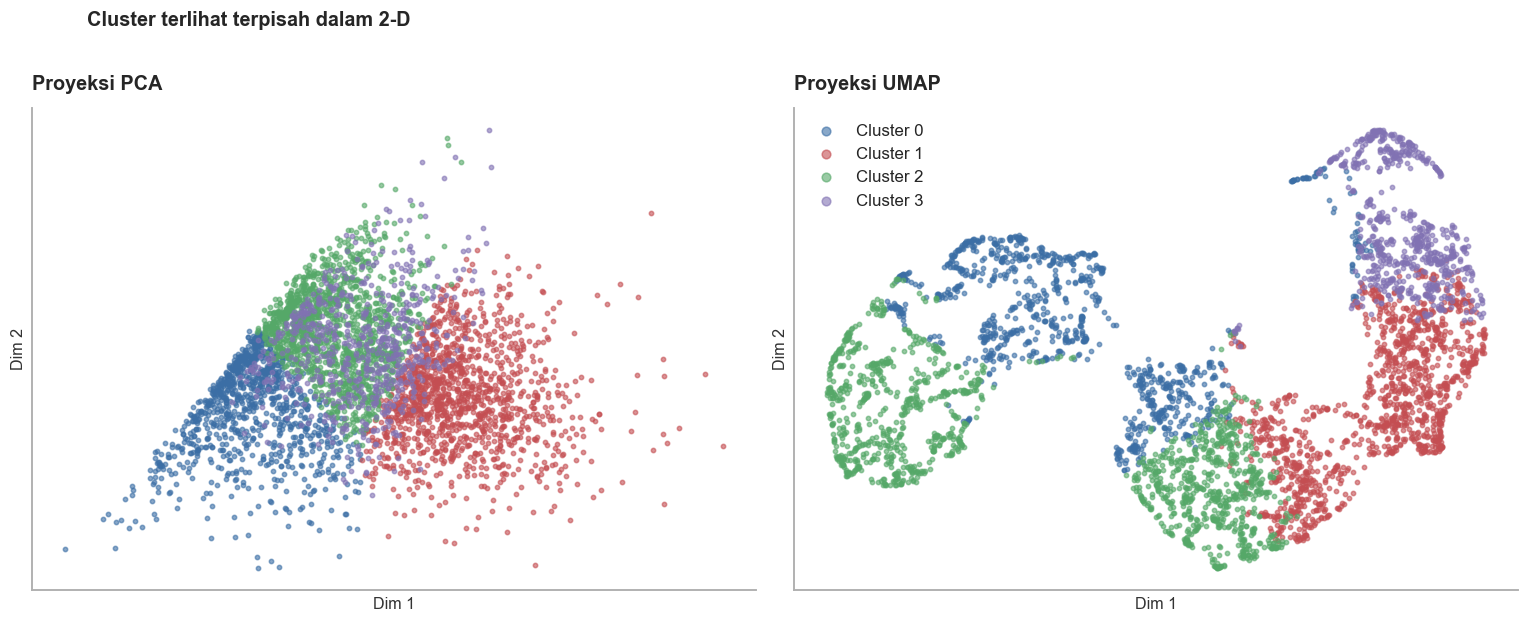

In [41]:
import umap

pca_2d = PCA(n_components=2, random_state=RANDOM_STATE).fit_transform(Xv)
umap_2d = umap.UMAP(n_components=2, random_state=RANDOM_STATE).fit_transform(Xv)

fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))
for ax, emb, title in [(axes[0], pca_2d, "Proyeksi PCA"),
                       (axes[1], umap_2d, "Proyeksi UMAP")]:
    for i in sorted(set(final_labels)):
        m = final_labels == i
        ax.scatter(emb[m, 0], emb[m, 1], s=8, alpha=0.6,
                   color=SEQ[i % len(SEQ)], label=f"Cluster {i}")
    ax.set_title(title); ax.set_xlabel("Dim 1"); ax.set_ylabel("Dim 2")
    ax.set_xticks([]); ax.set_yticks([])
axes[1].legend(markerscale=2, loc="best")
fig.suptitle("Cluster terlihat terpisah dalam 2-D", y=1.02,
             fontsize=13, fontweight="bold", x=0.06, ha="left")
plt.tight_layout(); plt.show()

### 8.2 Membaca profil tiap segmen
Kita rangkum tiap cluster lewat nilai tengah (median) perilaku utamanya, lalu urutkan
dari yang paling terlibat sampai yang paling pasif, dan beri satu nama persona per
peringkat. Cara pengurutan ini menjamin namanya selalu jelas dan tidak tumpang
tindih, berapa pun urutan cluster yang keluar.

Satu catatan jujur soal penamaan: nama-nama ini bersifat **relatif** terhadap basis
pelanggan toko ini, bukan patokan mutlak. Toko dengan pembelian yang umumnya jarang
tetap punya segmen "teratas" secara relatif. Jadi bacalah label sebagai posisi
dibanding pelanggan lain, bukan klaim absolut.


In [42]:
profile = customers.groupby("Cluster")[features].median()
profile["Pelanggan"] = customers["Cluster"].value_counts().sort_index()
profile["Revenue"] = customers.groupby("Cluster")["Monetary"].sum()
profile["Revenue_share_%"] = (profile["Revenue"] / profile["Revenue"].sum() * 100).round(1)
profile.round(2)

,Recency,Frequency,Monetary,AOV,Tenure,AvgBasketSize,ProductDiversity,ReturnRate,Pelanggan,Revenue,Revenue_share_%
Cluster,,,,,,,,,,,
0,131.0,1.0,186.01,138.14,0.0,6.50,8.0,0.00,983,268001.04,3.1
1,16.0,7.0,2424.49,345.94,297.0,19.96,99.0,0.12,1308,6771802.60,77.4
2,70.0,2.0,505.18,314.40,0.0,24.00,35.0,0.00,1389,900896.67,10.3
3,74.0,2.0,716.92,332.23,72.0,17.00,33.0,0.40,654,803213.33,9.2


In [43]:
# Urutkan cluster terbaik->terlemah berdasar skor keterlibatan gabungan.
rank = (profile["Recency"].rank(ascending=True)
        + profile["Frequency"].rank(ascending=False)
        + profile["Monetary"].rank(ascending=False))
ordered = rank.sort_values().index.tolist()
ladder = ["Juara", "Setia", "Calon Setia", "Berisiko",
          "Hibernasi", "Hilang", "Sesekali", "Pinggiran"]
name_map = {c: ladder[i] for i, c in enumerate(ordered)}
customers["Segmen"] = customers["Cluster"].map(name_map)

print("Cluster -> Segmen (urut dari keterlibatan terkuat ke terlemah):")
for c in ordered:
    p = profile.loc[c]
    print(f"  cluster {c} -> {name_map[c]:<14} "
          f"(R={p['Recency']:.0f}, F={p['Frequency']:.0f}, M={p['Monetary']:,.0f})")

Cluster -> Segmen (urut dari keterlibatan terkuat ke terlemah):
  cluster 1 -> Juara          (R=16, F=7, M=2,424)
  cluster 2 -> Setia          (R=70, F=2, M=505)
  cluster 3 -> Calon Setia    (R=74, F=2, M=717)
  cluster 0 -> Berisiko       (R=131, F=1, M=186)


In [44]:
seg = (customers.groupby("Segmen")
       .agg(Pelanggan=("Recency", "size"),
            Recency=("Recency", "median"), Frequency=("Frequency", "median"),
            Monetary=("Monetary", "median"), Revenue=("Monetary", "sum"))
       .sort_values("Revenue", ascending=False))
seg["Revenue_share_%"] = (seg["Revenue"] / seg["Revenue"].sum() * 100).round(1)
seg["Pelanggan_share_%"] = (seg["Pelanggan"] / seg["Pelanggan"].sum() * 100).round(1)
seg.round(1)

,Pelanggan,Recency,Frequency,Monetary,Revenue,Revenue_share_%,Pelanggan_share_%
Segmen,,,,,,,
Juara,1308,16.0,7.0,2424.5,6771802.6,77.4,30.2
Setia,1389,70.0,2.0,505.2,900896.7,10.3,32.0
Calon Setia,654,74.0,2.0,716.9,803213.3,9.2,15.1
Berisiko,983,131.0,1.0,186.0,268001.0,3.1,22.7


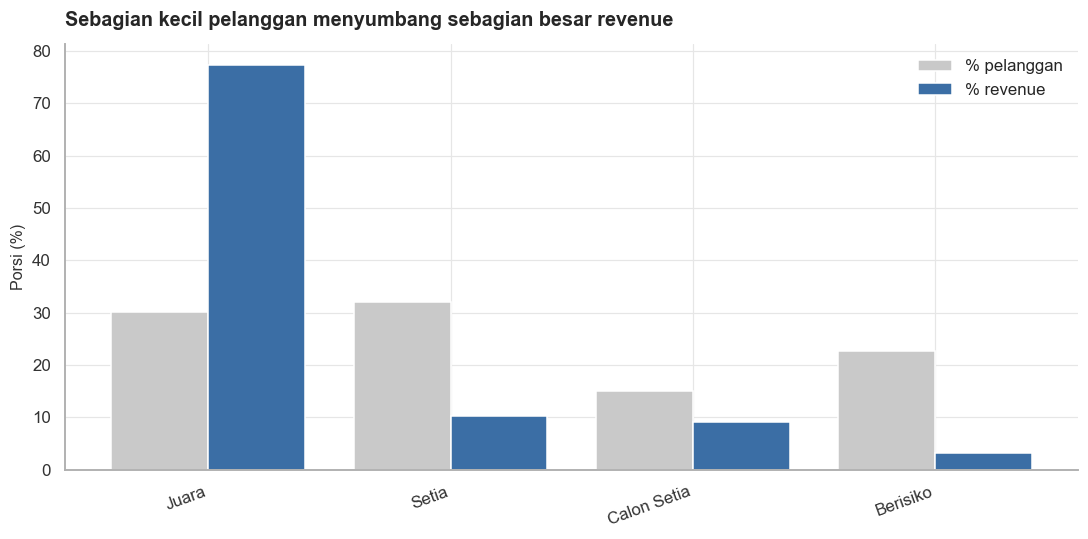

In [45]:
order = seg.index.tolist()
xpos = np.arange(len(order)); w = 0.4
fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(xpos - w/2, seg["Pelanggan_share_%"], w, label="% pelanggan", color=MUTED)
ax.bar(xpos + w/2, seg["Revenue_share_%"], w, label="% revenue", color=PRIMARY)
ax.set_xticks(xpos); ax.set_xticklabels(order, rotation=20, ha="right")
ax.set_ylabel("Porsi (%)")
ax.set_title("Sebagian kecil pelanggan menyumbang sebagian besar revenue")
ax.legend()
plt.tight_layout(); plt.show()

**Apa artinya ini.** Yang muncul adalah ketimpangan khas dunia retail:
segmen teratas jumlahnya sedikit tapi menyumbang porsi revenue paling besar,
sementara kelompok yang berisiko atau sudah pasif jumlahnya banyak tapi sumbangannya
kecil. Justru ketimpangan inilah yang membuat segmentasi berharga - ia menunjukkan
dengan tepat di mana tiap rupiah pemasaran paling berbuah.


## 9. Menerjemahkan jadi rekomendasi bisnis

Segmentasi baru ada gunanya kalau mengubah tindakan. Jadi tiap segmen saya beri tiga
hal: diagnosis singkat, aksi yang disarankan, dan alasannya - semuanya diurutkan
berdasarkan seberapa besar revenue yang dipertaruhkan, supaya usaha diarahkan ke
tempat yang imbal hasilnya paling besar.


In [46]:
playbook = {
    "Juara": ("Pelanggan terbaik: baru, sering, belanja tinggi.",
        "Hadiahi & pertahankan - perk VIP, akses awal, insentif referral. Jangan "
        "diskon; jaga margin."),
    "Setia": ("Pembeli konsisten dan bernilai.",
        "Tingkatkan share of wallet - cross-sell tertarget dan tingkatan loyalitas."),
    "Calon Setia": ("Pembeli baru dengan keterlibatan menaik.",
        "Bina menuju loyalitas - seri onboarding, insentif pembelian kedua, "
        "rekomendasi personal."),
    "Berisiko": ("Dulu terlibat, kini mulai diam.",
        "Win-back sebelum churn - tawaran reaktivasi pada kategori favorit mereka; "
        "nilai pemulihan per kontak tinggi."),
    "Hibernasi": ("Lama tidak aktif, nilai rendah.",
        "Hanya win-back otomatis berbiaya rendah; jangan investasi berlebih."),
    "Hilang": ("Praktis churn, nilai minimal.",
        "De-prioritaskan - masukkan hanya ke kampanye luas nyaris tanpa biaya."),
}

rows = []
for s in seg.index:
    diag, action = playbook.get(s, ("--", "--"))
    rows.append({"Segmen": s, "Pelanggan": int(seg.loc[s, "Pelanggan"]),
                 "Revenue_dipertaruhkan": round(seg.loc[s, "Revenue"]),
                 "Diagnosis": diag, "Aksi yang disarankan": action})
pd.set_option("display.max_colwidth", 70)
action_plan = pd.DataFrame(rows)
action_plan

,Segmen,Pelanggan,Revenue_dipertaruhkan,Diagnosis,Aksi yang disarankan
0,Juara,1308,6771803,"Pelanggan terbaik: baru, sering, belanja tinggi.","Hadiahi & pertahankan - perk VIP, akses awal, insentif referral. J..."
1,Setia,1389,900897,Pembeli konsisten dan bernilai.,Tingkatkan share of wallet - cross-sell tertarget dan tingkatan lo...
2,Calon Setia,654,803213,Pembeli baru dengan keterlibatan menaik.,"Bina menuju loyalitas - seri onboarding, insentif pembelian kedua,..."
3,Berisiko,983,268001,"Dulu terlibat, kini mulai diam.",Win-back sebelum churn - tawaran reaktivasi pada kategori favorit ...


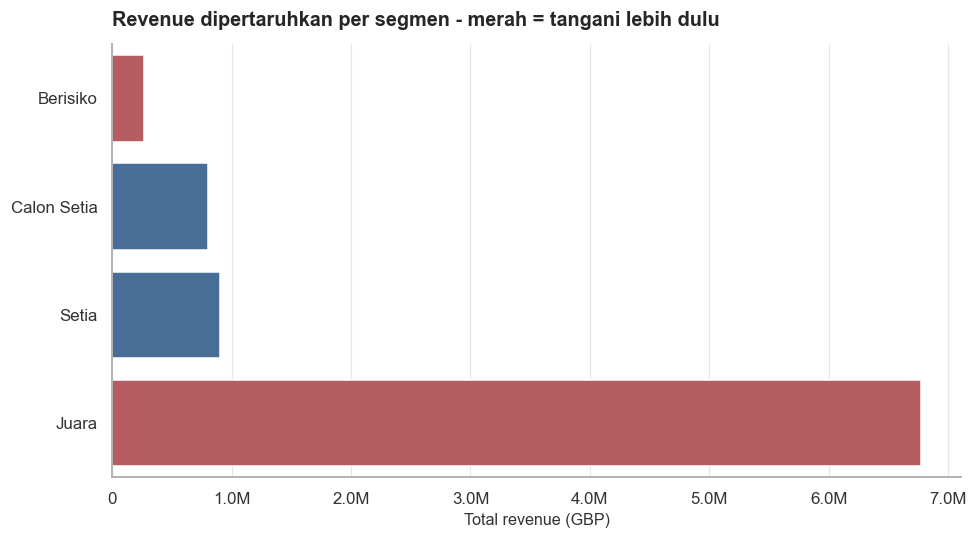

In [47]:
prio = seg.sort_values("Revenue")
colors_p = [ACCENT if s in ("Berisiko", "Juara") else PRIMARY for s in prio.index]
fig, ax = plt.subplots(figsize=(9, 5))
barplot(ax, prio["Revenue"].values, prio.index, colors_p)
ax.set_title("Revenue dipertaruhkan per segmen - merah = tangani lebih dulu")
ax.set_xlabel("Total revenue (GBP)"); ax.set_ylabel("")
thousands(ax, "x")
plt.tight_layout(); plt.show()

## Penutup

Berangkat dari satu tahun transaksi mentah yang tak terpilah, perjalanan ini:

1. **Merumuskan** masalah bisnis yang nyata - mahalnya memperlakukan semua pelanggan
   dengan cara yang sama.
2. **Membersihkan** data jadi penjualan asli yang jelas pemiliknya, lewat proses
   yang transparan.
3. **Membuktikan** temuan EDA dengan uji hipotesis - lonjakan Q4 (Mann-Whitney) dan
   hubungan harga-kuantitas (Kruskal-Wallis) dua-duanya nyata secara statistik.
4. **Merangkai** delapan fitur perilaku dari pengetahuan bisnis retail (dengan
   definisi AvgBasketSize dan ReturnRate yang sudah benar).
5. **Menyiapkan** data lewat satu pipeline bebas kebocoran, dan memakai PCA untuk
   membenarkan keputusan memodelkan di ruang fitur penuh.
6. **Mengadu** empat algoritma clustering (K-Means, GMM via BIC, DBSCAN, HDBSCAN)
   pada tiga metrik, lalu memilih K-Means berdasarkan bukti.
7. **Menguji** kualitas dan kestabilannya, bukan sekadar percaya begitu saja.
8. **Mengenali** tiap cluster jadi persona bernama, dikonfirmasi lewat gambar PCA
   dan UMAP.
9. **Meresepkan** aksi yang diprioritaskan untuk tiap segmen.

**Intinya buat bisnis:** revenue menumpuk di segelintir pelanggan bernilai tinggi.
Lindungi para Juara, dahulukan menarik kembali segmen Berisiko (di situ revenue
paling mungkin diselamatkan), rawat Calon Setia, dan cukup andalkan jangkauan
otomatis berbiaya rendah untuk sisanya.

**Kalau mau dilanjutkan:** pantau perpindahan pelanggan antar segmen dari waktu ke
waktu, uji A/B rekomendasi di atas, dan tambahkan fitur kedekatan produk untuk
menajamkan penawaran cross-sell.
